# Evaluation - Robustness to perturbations

Accuracy vs increasing perturbation strength (JPEG compression, Gaussian blur, downsampling, additive noise) on a test subsample. Covers the image-input pipelines.

**Sections:** 0 Setup - 1 Sweep - 2 Curves - 3 Robustness summary

> Reads each pipeline's committed artifacts and reconstructs trained models via `utils.eval_protocols` (rebuilt from `best_params.json`). Run after training completes.

## 0 - Setup

In [1]:
import sys, json, math
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

_here = Path.cwd()
_nb = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb) not in sys.path:
    sys.path.insert(0, str(_nb))

from utils import eval_protocols as EP, metrics as Me, viz as V, datasets as D, explain as E, eda

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EP.ART / "evaluation" / "figures"
OUT.mkdir(parents=True, exist_ok=True)
TAB = EP.ART / "evaluation"
PIPES = EP.available()
print("device:", device)
print("pipelines with trained results:", PIPES)
IMG_PIPES = [n for n in PIPES if EP.SPEC[n]["family"] == "image"]
SUBSAMPLE = 800      # test images per perturbation level (lower = faster; 800 keeps accuracy ~+/-3%)
NUM_WORKERS = 8      # parallel CPU perturbation prep -> keeps the GPU fed (the main speedup). Set 0 if interactive workers misbehave.
print("image-input pipelines:", IMG_PIPES)
print("subsample:", SUBSAMPLE, "| num_workers:", NUM_WORKERS)
print("perturbations:", {k: v for k, v in EP.PERTURBATIONS.items()})

device: cuda
pipelines with trained results: ['cnn-scratch', 'cnn-residual', 'cnn-finetune', 'vit-lora', 'clip-probe', 'two-stream', 'freqcross', 'srm-noise', 'patch-ensemble', 'dire-recon']
image-input pipelines: ['cnn-scratch', 'cnn-residual', 'cnn-finetune', 'vit-lora', 'two-stream', 'freqcross', 'srm-noise']
subsample: 800 | num_workers: 8
perturbations: {'jpeg_quality': [100, 90, 80, 70, 60], 'gaussian_blur_sigma': [0.0, 0.5, 1.0, 1.5, 2.0], 'downsample_scale': [1.0, 0.75, 0.5, 0.35, 0.25], 'gaussian_noise_std': [0.0, 0.02, 0.05, 0.1, 0.15]}


> **Scope:** the sweep covers the **image-input** pipelines. `clip-probe`, `patch-ensemble` and `dire-recon` use specialized inputs (cached embeddings / patch bags / diffusion-reconstruction maps), so they're omitted from the pixel-perturbation sweep here.

## 1 - Run the perturbation sweep

For each pipeline, each perturbation type, each strength level: build a perturbed loader and measure accuracy. (GPU; ~minutes per pipeline.)

In [2]:
from tqdm.auto import tqdm

results = {kind: {n: [] for n in IMG_PIPES} for kind in EP.PERTURBATIONS}
total = len(IMG_PIPES) * sum(len(v) for v in EP.PERTURBATIONS.values())   # e.g. 7 pipelines x 20 = 140 points
pbar = tqdm(total=total, desc="robustness sweep")
for n in IMG_PIPES:
    model = EP.load_model(n, device)
    for kind, levels in EP.PERTURBATIONS.items():
        accs = []
        for lv in levels:
            r = EP.robustness_point(n, model, kind, lv, device, subsample=SUBSAMPLE, num_workers=NUM_WORKERS)
            accs.append(r["accuracy"])
            pbar.update(1); pbar.set_postfix_str(f"{n} | {kind}={lv}")
        results[kind][n] = accs
        tqdm.write(f"{n:16s} {kind:20s} {[round(a, 3) for a in accs]}")   # per-(pipeline,perturbation) result line
    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
pbar.close()

robustness sweep:   0%|          | 0/140 [00:00<?, ?it/s]

cnn-scratch      jpeg_quality         [0.9, 0.897, 0.901, 0.899, 0.89]
cnn-scratch      gaussian_blur_sigma  [0.899, 0.899, 0.895, 0.894, 0.896]
cnn-scratch      downsample_scale     [0.899, 0.839, 0.714, 0.652, 0.581]
cnn-scratch      gaussian_noise_std   [0.899, 0.606, 0.556, 0.541, 0.544]
cnn-residual     jpeg_quality         [0.781, 0.784, 0.789, 0.79, 0.787]
cnn-residual     gaussian_blur_sigma  [0.784, 0.781, 0.78, 0.786, 0.784]
cnn-residual     downsample_scale     [0.784, 0.757, 0.69, 0.69, 0.662]
cnn-residual     gaussian_noise_std   [0.784, 0.66, 0.631, 0.604, 0.514]
cnn-finetune     jpeg_quality         [0.93, 0.935, 0.932, 0.943, 0.946]
cnn-finetune     gaussian_blur_sigma  [0.934, 0.939, 0.949, 0.951, 0.949]
cnn-finetune     downsample_scale     [0.934, 0.954, 0.891, 0.806, 0.748]
cnn-finetune     gaussian_noise_std   [0.934, 0.882, 0.619, 0.51, 0.497]
vit-lora         jpeg_quality         [0.975, 0.975, 0.978, 0.98, 0.973]
vit-lora         gaussian_blur_sigma  [0.974, 0.9

## 2 - Robustness curves

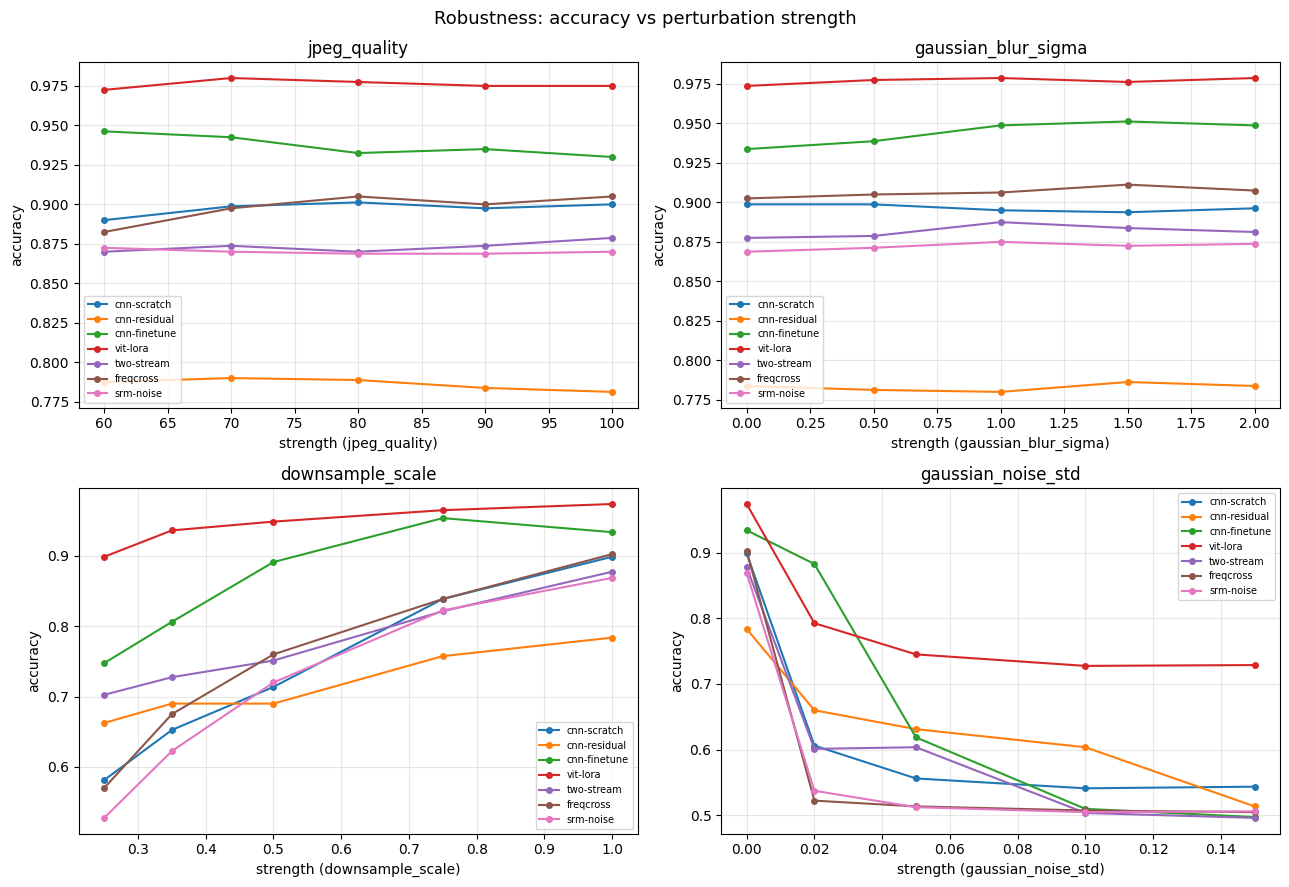

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.reshape(-1)
for ax, (kind, levels) in zip(axes, EP.PERTURBATIONS.items()):
    for n in IMG_PIPES:
        ax.plot(levels, results[kind][n], marker="o", ms=4, label=n)
    ax.set_title(kind); ax.set_xlabel("strength (" + kind + ")"); ax.set_ylabel("accuracy"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
fig.suptitle("Robustness: accuracy vs perturbation strength", fontsize=13); fig.tight_layout()
fig.savefig(OUT / "robustness_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 3 - Robustness summary (mean accuracy across all perturbed conditions)

In [4]:
rows = []
for n in IMG_PIPES:
    allv = [a for kind in EP.PERTURBATIONS for a in results[kind][n]]
    clean = results["jpeg_quality"][n][0]  # quality 100 ~ clean
    rows.append({"pipeline": n, "clean_acc": clean, "mean_perturbed_acc": float(np.mean(allv)), "worst_acc": float(np.min(allv))})
rob = pd.DataFrame(rows).sort_values("mean_perturbed_acc", ascending=False).reset_index(drop=True)
display(rob.round(4)); rob.round(6).to_csv(TAB / "robustness_summary.csv", index=False)
print("Most robust:", rob.iloc[0]["pipeline"], "| least:", rob.iloc[-1]["pipeline"])

,pipeline,clean_acc,mean_perturbed_acc,worst_acc
0,vit-lora,0.9750,0.9228,0.7275
1,cnn-finetune,0.9300,0.8591,0.4975
2,cnn-scratch,0.9000,0.7901,0.5412
3,two-stream,0.8788,0.7869,0.4962
4,freqcross,0.9050,0.7860,0.5050
5,srm-noise,0.8700,0.7601,0.5050
6,cnn-residual,0.7812,0.7311,0.5138


Most robust: vit-lora | least: cnn-residual
